# SRDM Solar-Reflection Modulation Contours

Preliminary JUNO-focused contours for Verne SRDMBeam solar-reflection rates. The modulation amplitude convention matches the original daily-modulation analysis: `A = (max(R) - min(R)) / 2`, with fractional amplitude `A / mean(R)`.

Daily-rate CSVs and `summary.csv` are cached by default under `modulation_study/srdm_solar_reflection_rates/`. Pass `overwrite=True` to the plotting helper when you intentionally want to recompute a slice.


In [2]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if repo_root.name == 'modulation_study':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / 'modulation_study') not in sys.path:
    sys.path.insert(0, str(repo_root / 'modulation_study'))

import numpy as np
import matplotlib.pyplot as plt

from modulation_study.Modulation import (
    discover_srdm_solar_reflection_points,
    get_srdm_solar_reflection_contour_data,
    plot_srdm_solar_reflection_contour,
)
from modulation_study.isoangle import get_solar_angle_limits
from modulation_study.MeanFreePath import plot_srdm_flux_weighted_mfp


## Available Verne SRDMBeam Grid


In [3]:
points = discover_srdm_solar_reflection_points(FDMn=2, modulated_source='Verne')
masses = np.array([p['mX_MeV'] for p in points])
sigmas = np.array([p['sigma_e_cm2'] for p in points])
print(f'points: {len(points)}')
print(f'mass range [MeV]: {masses.min():.4g} - {masses.max():.4g}; count={len(np.unique(masses))}')
print(f'sigma range [cm^2]: {sigmas.min():.3g} - {sigmas.max():.3g}; count={len(np.unique(sigmas))}')
print(f'ring counts: {sorted(set(p["ring_count"] for p in points))}')


/home/ansh/Projects/SENSEI/DarkMatterRates/DMeRates/Constants.py:20: RuntimeWarning: numericalunits was imported before DMeRates. DMeRates re-randomizes the numericalunits base unit scales on its first import, so any quantities built with numericalunits before this point are no longer valid and must be re-created. Import DMeRates before numericalunits to avoid this warning.
  warnings.warn(


points: 445
mass range [MeV]: 0.01 - 3; count=25
sigma range [cm^2]: 1e-42 - 1e-33; count=19
ring counts: [36]


## JUNO Solar-Angle Envelope


In [4]:
date = [8, 8, 2024]
for site in ['JUNO', 'SNOLAB', 'SUPL']:
    low, high = get_solar_angle_limits(site, date)
    print(f'{site:6s}: {low:6.2f} - {high:6.2f} deg')


JUNO  :   6.38 - 141.77 deg
SNOLAB:  30.63 - 117.54 deg
SUPL  :  52.09 - 159.82 deg


## Absolute Amplitude Contour


/home/ansh/Projects/SENSEI/DarkMatterRates/modulation_study/Modulation.py:941: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


CUDA GPU found, performing calculations on GPU


Fetching SRDM Solar Reflection Data:   0%|          | 0/445 [00:00<?, ?it/s]

/home/ansh/Projects/SENSEI/DarkMatterRates/modulation_study/Modulation.py:1239: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize=(10, 8), layout="constrained")
/home/ansh/Projects/SENSEI/DarkMatterRates/modulation_study/Modulation.py:1276: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  cbar = fig.colorbar(contour, ax=ax)


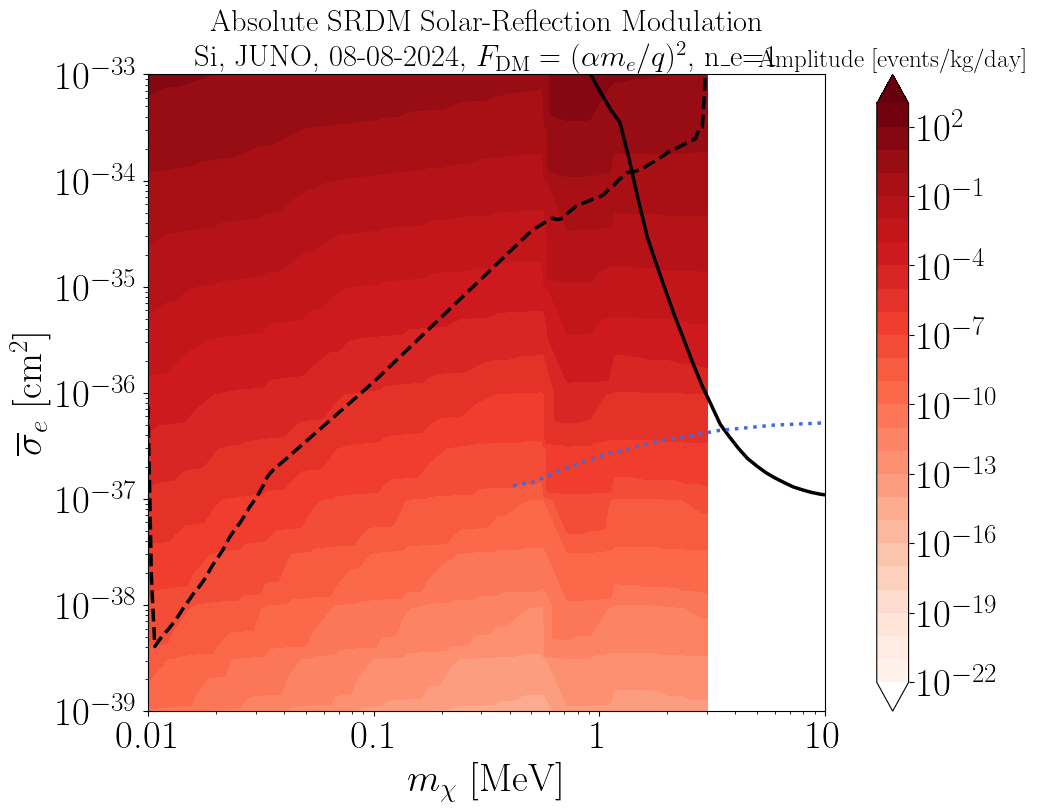

In [5]:
fig, ax, contour = plot_srdm_solar_reflection_contour(
    material='Si',
    FDMn=2,
    location='JUNO',
    date=date,
    ne=1,
    fractional=False,
    cadence_minutes=10,
    modulated_source='Verne',
    screening='rpa',
    variant='composite',
    mediator_spin='vector',
    form_factor_type='qcdark2',
    plot_solar_constraints=True,
    include_all_constraints=True,
    include_freeze_in=True,
    xlim=(1e-2, 1e1),
    ylim=(1e-39, 1e-33),
)
plt.show()


## Fractional Amplitude Contour


CUDA GPU found, performing calculations on GPU


Fetching SRDM Solar Reflection Data:   0%|          | 0/445 [00:00<?, ?it/s]

/home/ansh/Projects/SENSEI/DarkMatterRates/modulation_study/Modulation.py:1239: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize=(10, 8), layout="constrained")
/home/ansh/Projects/SENSEI/DarkMatterRates/modulation_study/Modulation.py:1276: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  cbar = fig.colorbar(contour, ax=ax)


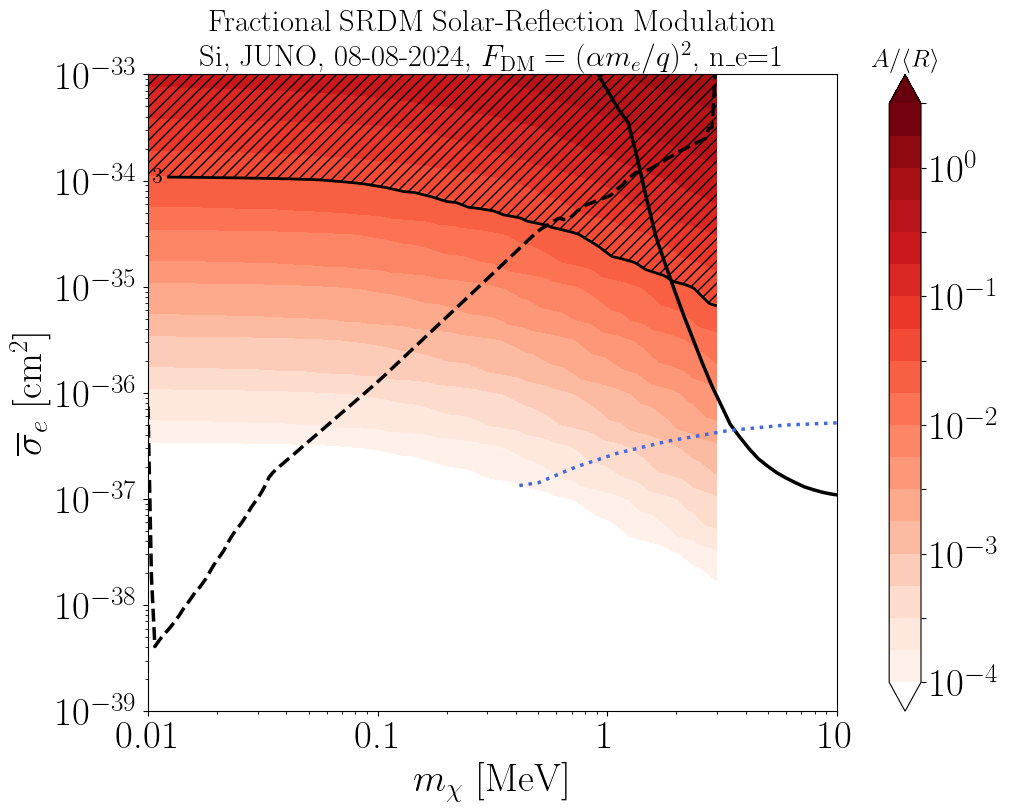

In [6]:
fig, ax, contour = plot_srdm_solar_reflection_contour(
    material='Si',
    FDMn=2,
    location='JUNO',
    date=date,
    ne=1,
    fractional=True,
    cadence_minutes=10,
    modulated_source='Verne',
    screening='rpa',
    variant='composite',
    mediator_spin='vector',
    form_factor_type='qcdark2',
    shade_fractional_threshold=True,
    fractional_threshold=0.03,
    plot_solar_constraints=True,
    include_all_constraints=True,
    include_freeze_in=True,
    xlim=(1e-2, 1e1),
    ylim=(1e-39, 1e-33),
)
plt.show()


## Flux-weighted SRDM Mean Free Path

This uses the direct incoming SRDM flux grid and computes `1 / <1/lambda(v)>_Phi` for the light mediator. The dashed black line overlays the cached `A/<R> = 3%` daily-modulation contour when available.


In [1]:
fig, ax, contour = plot_srdm_flux_weighted_mfp(
    FDMn=2,
    mediator_spin='vector',
    grid_family='srdm_fdmq2_source_v1',
    r_fraction=0.8,
    grid_size=300,
    overlay_fractional_modulation=False,
    fractional_threshold=0.03,
    modulation_kwargs=dict(location='JUNO', date=date, ne=1),
    plot_solar_constraints=True,
    include_all_constraints=True,
    include_freeze_in=True,
    xlim=(1e-2, 1e1),
    ylim=(1e-39, 1e-33),
)
plt.show()


NameError: name 'plot_srdm_flux_weighted_mfp' is not defined